# Onion Price Predictive Dashboard (OPPD)

This notebook contains the complete pipeline for the OPPD system. Since we need to predict using future inputs (where weather is unknown), we are building a two-stage pipeline in this unified notebook:
1. **Weather Predictor Model:** Predicts expected weather (temp, wind, rainfall) based on State, District, and Future Month.
2. **Price Range Predictor Model:** Predicts the `Min_Price`, `Max_Price`, and `Modal_Price` based on Location, Month, Variety, and the predicted weather.

*Note: In regression problems like this (predicting continuous numeric values), we evaluate models using metrics like **Mean Absolute Error (MAE)** and **R-Squared (R2)** rather than traditional "Accuracy," which is strictly a classification metric.*

### Pipeline Steps:
- Data Loading & Inspection
- Exploratory Data Analysis (EDA)
- Automated Anomaly & Outlier Normalization
- Data Preprocessing & 80-20 Train/Test Split
- Model Training & Evaluation (Random Forest, Bagging, Boosting, Decision Trees, etc.)
- Exporting the Best Estimator Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# 1. Load the dataset
df = pd.read_csv('onion_weather_data.csv')

# 2. Convert 'Price Date' to datetime objects to extract month/year later
if 'Price Date' in df.columns:
    df['Price Date'] = pd.to_datetime(df['Price Date'], errors='coerce')

# 3. Display basic info to understand null values and datatypes
print("--- Dataset Info ---")
df.info()

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Missing Values ---")
display(df.isnull().sum())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229302 entries, 0 to 229301
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   STATE          229302 non-null  object        
 1   District Name  229302 non-null  object        
 2   Market Name    229302 non-null  object        
 3   Variety        229302 non-null  object        
 4   Min_Price      229302 non-null  float64       
 5   Max_Price      229302 non-null  float64       
 6   Modal_Price    229302 non-null  float64       
 7   Price Date     229302 non-null  datetime64[ns]
 8   avg_temp       229302 non-null  float64       
 9   min_temp       229302 non-null  float64       
 10  max_temp       229302 non-null  float64       
 11  wind_speed     229302 non-null  float64       
 12  rainfall       229302 non-null  float64       
dtypes: datetime64[ns](1), float64(8), object(4)
memory usage: 22.7+ MB

--- First 5 Row

,STATE,District Name,Market Name,Variety,Min_Price,Max_Price,Modal_Price,Price Date,avg_temp,min_temp,max_temp,wind_speed,rainfall
0,rajasthan,pratapgarh,Pratapgarh,Other,476.0,1043.0,617.0,2023-06-06,31.240909,24.468182,38.618182,10.477273,0.554545
1,rajasthan,bharatpur,Bayana,Onion,1000.0,1000.0,1000.0,2023-06-06,31.240909,24.468182,38.618182,10.477273,0.554545
2,uttar pradesh,pratapgarh,Pratapgarh,Other,476.0,1043.0,617.0,2023-06-06,31.331250,23.690625,38.134375,8.500000,0.571875
3,uttar pradesh,bareilly,Bareilly,Red,1075.0,1150.0,1120.0,2023-06-06,31.331250,23.690625,38.134375,8.500000,0.571875
4,haryana,kaithal,Kaithal,1st Sort,700.0,1200.0,950.0,2023-06-06,29.200000,22.916667,36.733333,7.833333,0.333333



--- Missing Values ---


,0
STATE,0
District Name,0
Market Name,0
Variety,0
Min_Price,0
Max_Price,0
Modal_Price,0
Price Date,0
avg_temp,0
min_temp,0


### 2. Feature Engineering & Exploratory Data Analysis (EDA)

We need to extract `Month` and `Year` from the `Price Date` because seasonal trends are crucial for predicting crop prices. After that, we'll visualize the price distribution to identify the outliers mentioned in the SRS.

In [3]:
# Extract Date Features
df['Year'] = df['Price Date'].dt.year
df['Month'] = df['Price Date'].dt.month

print("Basic Statistical summary of Prices:")
display(df[['Min_Price', 'Modal_Price', 'Max_Price']].describe())

Basic Statistical summary of Prices:


,Min_Price,Modal_Price,Max_Price
count,229302.000000,229302.000000,229302.000000
mean,2565.576624,2941.949243,3194.080802
std,2280.736718,2326.684371,2535.283634
min,0.000000,8.000000,0.000000
25%,1400.000000,1690.000000,1900.000000
50%,2090.000000,2500.000000,2800.000000
75%,3550.000000,3900.000000,4150.000000
max,420000.000000,460000.000000,480000.000000


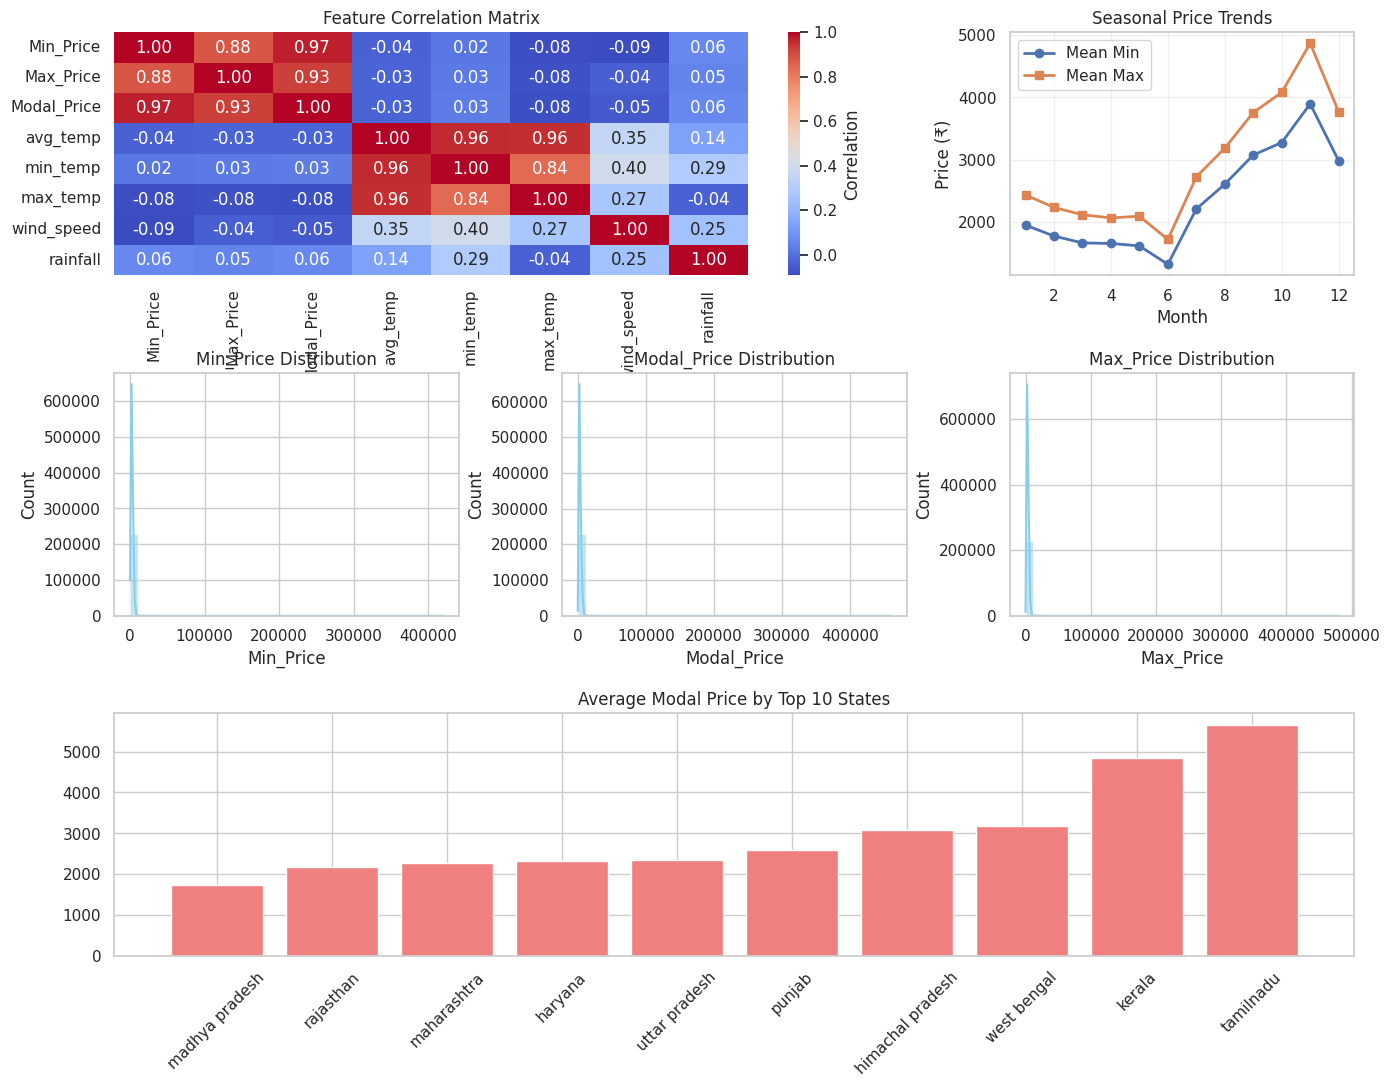

In [4]:
# Comprehensive Exploratory Data Analysis Structure
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# 1. Correlation heatmap for weather & price
ax1 = fig.add_subplot(gs[0, :2])
corr_cols = ['Min_Price', 'Max_Price', 'Modal_Price', 'avg_temp', 'min_temp',
             'max_temp', 'wind_speed', 'rainfall']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax1, cbar_kws={'label': 'Correlation'})
ax1.set_title('Feature Correlation Matrix')

# 2. Time series seasonal trend
ax2 = fig.add_subplot(gs[0, 2])
monthly_prices = df.groupby('Month')[['Min_Price', 'Max_Price']].mean()
ax2.plot(monthly_prices.index, monthly_prices['Min_Price'], marker='o', label='Mean Min', linewidth=2)
ax2.plot(monthly_prices.index, monthly_prices['Max_Price'], marker='s', label='Mean Max', linewidth=2)
ax2.set_xlabel('Month'); ax2.set_ylabel('Price (₹)'); ax2.set_title('Seasonal Price Trends')
ax2.legend(); ax2.grid(True, alpha=0.3)

# 3. Distribution plots with KDE
for idx, col in enumerate(['Min_Price', 'Modal_Price', 'Max_Price']):
    ax = fig.add_subplot(gs[1, idx])
    sns.histplot(df[col], kde=True, bins=40, ax=ax, color='skyblue')
    ax.set_title(f'{col} Distribution')

# 4. State-wise price comparison
ax5 = fig.add_subplot(gs[2, :])
top_states = df['STATE'].value_counts().head(10).index
state_prices = df[df['STATE'].isin(top_states)].groupby('STATE')['Modal_Price'].mean().sort_values()
ax5.bar(state_prices.index, state_prices.values, color='lightcoral')
ax5.set_title('Average Modal Price by Top 10 States')
plt.xticks(rotation=45)

plt.show()

### 3. Automated Anomaly & Shock Normalization (Handling Outliers)

Sudden market shocks or unnatural price crashes can skew our seasonal biological trends. We will use the Interquartile Range (IQR) method to filter out severe outliers in the `Modal_Price`.

Original Dataset Size: 229302
Cleaned Dataset Size: 225832
Removed 3470 outlier rows.
Modal Price valid range kept defined as: ₹100.00 to ₹7215.00


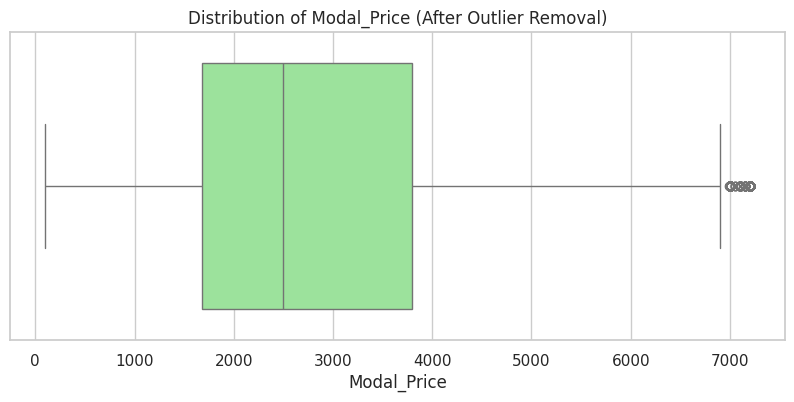

In [5]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Ensuring price doesn't go below a rational threshold (e.g., extremely low values like 50 paise)
    if lower_bound < 100:
        lower_bound = 100

    filtered_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return filtered_data, lower_bound, upper_bound

original_len = len(df)
df_clean, lower, upper = remove_outliers_iqr(df, 'Modal_Price')
clean_len = len(df_clean)

print(f"Original Dataset Size: {original_len}")
print(f"Cleaned Dataset Size: {clean_len}")
print(f"Removed {original_len - clean_len} outlier rows.")
print(f"Modal Price valid range kept defined as: ₹{lower:.2f} to ₹{upper:.2f}")

# Plotting the adjusted distribution
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean['Modal_Price'], color='lightgreen')
plt.title('Distribution of Modal_Price (After Outlier Removal)')
plt.show()

### 4. Data Preprocessing & Encoding

To feed our data into machine learning models, we need to convert textual categorical features (`STATE`, `District Name`, and `Variety`) into numeric values. We'll use Label Encoding for this.

In [6]:
from sklearn.preprocessing import LabelEncoder

# Initialize encoders
le_state = LabelEncoder()
le_district = LabelEncoder()
le_variety = LabelEncoder()

# Create a copy of clean data for modeling
df_model = df_clean.copy()

# Fit and transform
df_model['STATE_encoded'] = le_state.fit_transform(df_model['STATE'])
df_model['District_encoded'] = le_district.fit_transform(df_model['District Name'])
df_model['Variety_encoded'] = le_variety.fit_transform(df_model['Variety'])

print("Categorical encoding complete.")
print(f"Total Unique States: {len(le_state.classes_)}")
print(f"Total Unique Districts: {len(le_district.classes_)}")
print(f"Total Unique Varieties: {len(le_variety.classes_)}")

Categorical encoding complete.
Total Unique States: 24
Total Unique Districts: 308
Total Unique Varieties: 23


### 5. Stage 1 Pipeline: Weather Predictor Model Evaluation

Since we won't know the exact weather 1 to 12 months in the future, we must predict it based on the location and the month. We'll utilize an 80-20 Train-Test split. We will evaluate multiple algorithms here to determine the absolute best weather predictor before generating our environmental baselines.

Initiating Stage 1 Cross-Validation...

--- Cross-Validating RandomForest ---
RandomForest 5-Fold Avg R2: 0.740 (+/- 0.001)

--- Cross-Validating ExtraTrees ---
ExtraTrees 5-Fold Avg R2: 0.741 (+/- 0.001)

--- Cross-Validating XGBoost ---
XGBoost 5-Fold Avg R2: 0.741 (+/- 0.001)


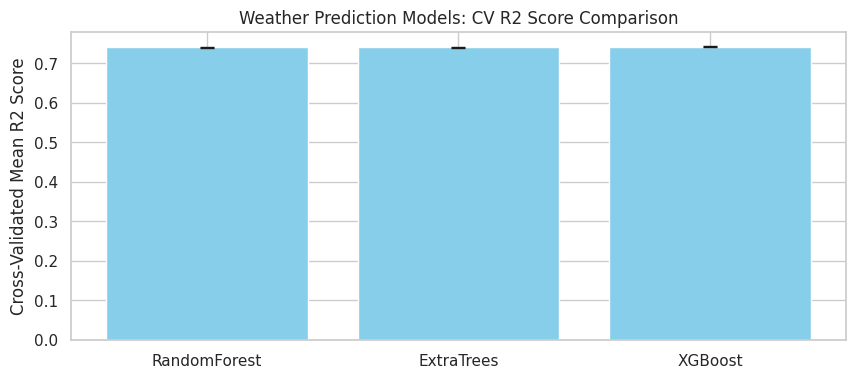


🏆 Best Weather Model Automatically Selected: XGBoost


In [7]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# Prepare Features & Targets for Weather
X_weather = df_model[['STATE_encoded', 'District_encoded', 'Month']].reset_index(drop=True)
y_weather = df_model[['avg_temp', 'min_temp', 'max_temp', 'wind_speed', 'rainfall']].reset_index(drop=True)

# 5-Fold Cross Validation Setup for Weather Prediction
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_evaluate_weather(models, X, y, cv_strategy):
    results = {}
    for name, model in models.items():
        print(f"\n--- Cross-Validating {name} ---")
        multi_target_model = MultiOutputRegressor(model)

        fold_r2 = []
        for train_idx, test_idx in cv_strategy.split(X):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

            multi_target_model.fit(X_tr, y_tr)
            preds = multi_target_model.predict(X_te)

            # Mean R2 across the 5 targets for this fold
            fold_r2.append(np.mean([r2_score(y_te.iloc[:, i], preds[:, i]) for i in range(y.shape[1])]))

        mean_r2 = np.mean(fold_r2)
        std_r2 = np.std(fold_r2)

        # Fit on full data for final use
        multi_target_model.fit(X, y)

        results[name] = {
            'model': multi_target_model,
            'CV_Mean_R2': mean_r2,
            'CV_Std_R2': std_r2
        }
        print(f"{name} 5-Fold Avg R2: {mean_r2:.3f} (+/- {std_r2:.3f})")

    return results

weather_models = {
    'RandomForest': RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
}

print("Initiating Stage 1 Cross-Validation...")
weather_results = cv_evaluate_weather(weather_models, X_weather, y_weather, kf)

# Visualization of Weather Evaluation
w_model_names = list(weather_results.keys())
w_cv_scores = [weather_results[m]['CV_Mean_R2'] for m in w_model_names]
w_cv_stds = [weather_results[m]['CV_Std_R2'] for m in w_model_names]

plt.figure(figsize=(10, 4))
plt.bar(w_model_names, w_cv_scores, yerr=w_cv_stds, color='skyblue', capsize=5)
plt.ylabel('Cross-Validated Mean R2 Score')
plt.title('Weather Prediction Models: CV R2 Score Comparison')
plt.show()

# Select Best Weather Model
best_weather_model_name = max(weather_results, key=lambda m: weather_results[m]['CV_Mean_R2'])
print(f"\n🏆 Best Weather Model Automatically Selected: {best_weather_model_name}")
weather_rf = weather_results[best_weather_model_name]['model']

### 6. Stage 2 Pipeline: Price Range Predictor Model Evaluation

Now we build the core model to predict `Min_Price` and `Max_Price` given the geographical location, crop variety, temporal data, and weather parameters. We will evaluate our chosen algorithms against additional tree-based regressors to finalize the most accurate model.

Initiating Stage 2 Complete CV Evaluation...

--- Cross-Validating RandomForest ---
5-Fold Avg MAE: ₹331.75 | Avg R2: 0.799

--- Cross-Validating GradientBoosting ---
5-Fold Avg MAE: ₹441.17 | Avg R2: 0.751

--- Cross-Validating XGBoost ---
5-Fold Avg MAE: ₹378.07 | Avg R2: 0.776

--- Cross-Validating StackingEnsemble ---
5-Fold Avg MAE: ₹500.61 | Avg R2: 0.726


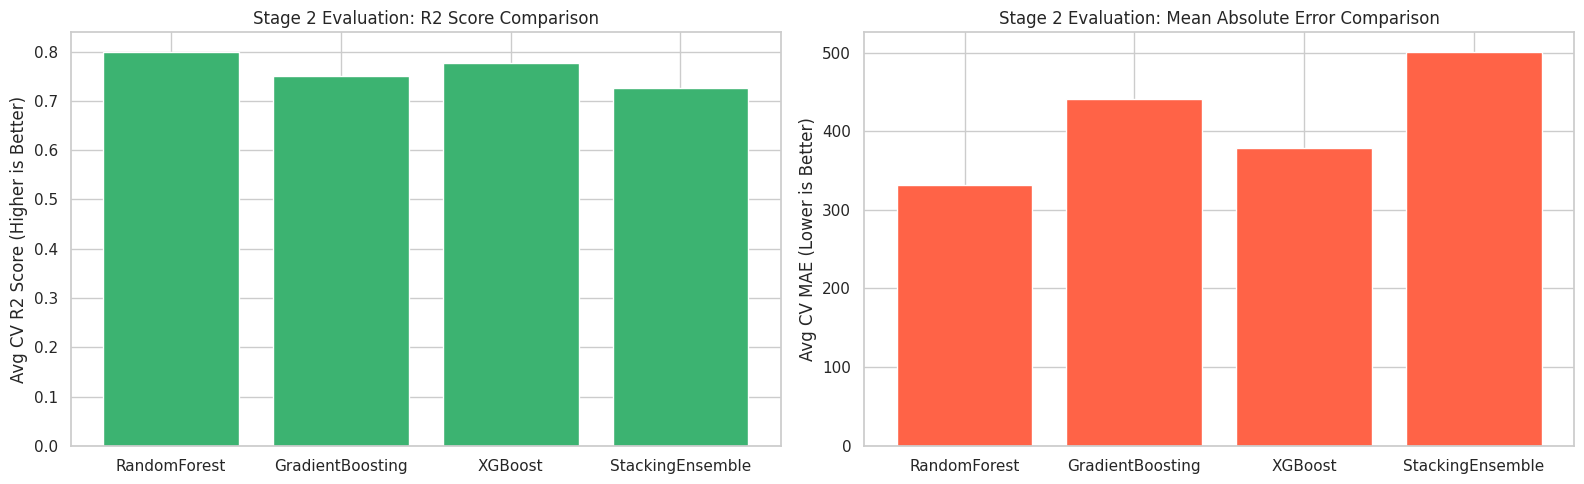


🏆 Best Final Price Model Selected: RandomForest


In [8]:
from sklearn.model_selection import KFold
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Context Features for Price Prediction
X_price = df_model[['STATE_encoded', 'District_encoded', 'Variety_encoded', 'Month', 'Year',
                    'avg_temp', 'min_temp', 'max_temp', 'wind_speed', 'rainfall']].reset_index(drop=True)

# Target Variables: Range (Min and Max)
y_price = df_model[['Min_Price', 'Max_Price']].reset_index(drop=True)

kf_price = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_evaluate_price(models, X, y, cv_strategy):
    results = {}
    for name, model in models.items():
        print(f"\n--- Cross-Validating {name} ---")
        # Ensure we can handle multi-output
        if not name == 'StackingEnsemble':
            multi_target_model = MultiOutputRegressor(model)
        else:
            multi_target_model = model # Stacking is manually wrapped below

        fold_mae = []
        fold_r2 = []

        for train_idx, test_idx in cv_strategy.split(X):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

            multi_target_model.fit(X_tr, y_tr)
            preds = multi_target_model.predict(X_te)

            fold_mae.append(mean_absolute_error(y_te, preds))
            fold_r2.append(np.mean([r2_score(y_te.iloc[:, i], preds[:, i]) for i in range(y.shape[1])]))

        cv_mean_mae = np.mean(fold_mae)
        cv_mean_r2 = np.mean(fold_r2)

        # Fit final model on everything
        multi_target_model.fit(X, y)

        results[name] = {
            'model': multi_target_model,
            'CV_Mean_MAE': cv_mean_mae,
            'CV_Mean_R2': cv_mean_r2
        }

        print(f"5-Fold Avg MAE: ₹{cv_mean_mae:.2f} | Avg R2: {cv_mean_r2:.3f}")

    return results

# Base Regressors for Advanced Modeling
price_models = {
    'RandomForest': RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=6, subsample=0.8, random_state=42, n_jobs=-1)
}

# Add Stacking Regressor (Combines powers of all base learners)
base_learners = [
    ('xgb', xgb.XGBRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)),
    ('rf', RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1))
]
meta_learner = Ridge(alpha=1.0)
stacking = MultiOutputRegressor(StackingRegressor(estimators=base_learners, final_estimator=meta_learner, cv=3))

price_models['StackingEnsemble'] = stacking

print("Initiating Stage 2 Complete CV Evaluation...")
model_results = cv_evaluate_price(price_models, X_price, y_price, kf_price)

# --- Visual Comparison of Final Models ---
model_names = list(model_results.keys())
cv_r2s = [model_results[m]['CV_Mean_R2'] for m in model_names]
cv_maes = [model_results[m]['CV_Mean_MAE'] for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# R2 Score Plot
axes[0].bar(model_names, cv_r2s, color='mediumseagreen')
axes[0].set_ylabel('Avg CV R2 Score (Higher is Better)')
axes[0].set_title('Stage 2 Evaluation: R2 Score Comparison')

# MAE Plot
axes[1].bar(model_names, cv_maes, color='tomato')
axes[1].set_ylabel('Avg CV MAE (Lower is Better)')
axes[1].set_title('Stage 2 Evaluation: Mean Absolute Error Comparison')

plt.tight_layout()
plt.show()

# Select Best Pricing Model Automatically
best_model_name = max(model_results, key=lambda m: model_results[m]['CV_Mean_R2'])
print(f"\n🏆 Best Final Price Model Selected: {best_model_name}")
final_price_model = model_results[best_model_name]['model']

### 7. End-to-End Prediction Inference & Export

Now that we have both stages complete, we construct a function mimicking how the Streamlit dashboard will use this pipeline:
1. Translates human text inputs to encoded categories.
2. Predicts future weather using Stage 1.
3. Passes weather and inputs to Stage 2 to predict the `Min` and `Max` Price Range.

In [9]:
import joblib
import datetime

# Best model was automatically selected and assigned to `final_price_model` in the previous cell.

def generate_forecast(state, district, variety, months_ahead):
    # Current date baseline
    current_date = datetime.datetime.now()
    future_date = current_date + pd.DateOffset(days=30 * months_ahead)
    target_month = future_date.month
    target_year = future_date.year

    # 1. Encode Inputs
    try:
        s_enc = le_state.transform([state])[0]
        d_enc = le_district.transform([district])[0]
        v_enc = le_variety.transform([variety])[0]
    except ValueError as e:
        return f"Error: {e}. Ensure region/variety exists in historical dataset."

    # 2. Predict Weather (Stage 1)
    weather_input = pd.DataFrame({'STATE_encoded': [s_enc], 'District_encoded': [d_enc], 'Month': [target_month]})
    pred_weather = weather_rf.predict(weather_input)[0]

    # 3. Predict Price Range (Stage 2)
    price_input = pd.DataFrame({
        'STATE_encoded': [s_enc], 'District_encoded': [d_enc], 'Variety_encoded': [v_enc],
        'Month': [target_month], 'Year': [target_year],
        'avg_temp': [pred_weather[0]], 'min_temp': [pred_weather[1]], 'max_temp': [pred_weather[2]],
        'wind_speed': [pred_weather[3]], 'rainfall': [pred_weather[4]]
    })

    pred_price = final_price_model.predict(price_input)[0]
    min_price = max(pred_price[0], 100) # Boundary enforcement as seen in outliers
    max_price = max(pred_price[1], 100)

    # FRP Extraction (UC-2)
    frp_value = min_price

    print(f"--- FORECAST FOR {months_ahead} MONTHS AHEAD ({future_date.strftime('%B %Y')}) ---")
    print(f"Location: {district.title()}, {state.title()} | Variety: {variety}")
    print(f"Predicted Weather -> Temp: {pred_weather[0]:.1f}°C, Rainfall: {pred_weather[4]:.2f}mm")
    print(f"💰 EXPECTED PRICE RANGE: ₹{min_price:.2f} to ₹{max_price:.2f} per Quintal")
    print(f"🛡️ SUGGESTED FRP (Lowest expected): ₹{frp_value:.2f}")

# Example inference
sample_state = df_clean['STATE'].iloc[0]
sample_district = df_clean['District Name'].iloc[0]
sample_variety = df_clean['Variety'].iloc[0]

generate_forecast(sample_state, sample_district, sample_variety, months_ahead=3)

# Exporting artifacts for Streamlit UI
joblib.dump(weather_rf, 'weather_model.pkl')
joblib.dump(final_price_model, 'price_model.pkl')
joblib.dump({'state': le_state, 'district': le_district, 'variety': le_variety}, 'label_encoders.pkl')
print("\n[SUCCESS] Pipeline executed and models exported successfully over to .pkl files for Streamlit deployment!")

--- FORECAST FOR 3 MONTHS AHEAD (August 2026) ---
Location: Pratapgarh, Rajasthan | Variety: Other
Predicted Weather -> Temp: 28.4°C, Rainfall: 6.00mm
💰 EXPECTED PRICE RANGE: ₹2351.29 to ₹3306.36 per Quintal
🛡️ SUGGESTED FRP (Lowest expected): ₹2351.29

[SUCCESS] Pipeline executed and models exported successfully over to .pkl files for Streamlit deployment!
